Nama: Amanda Desi Dwi Nilamsari Husnaa

NIM: 220322696361

# Komputasi Persamaan Differensial Biasa

---

## Tugas 1
Selesaikan latihan 1 menggunakan differensial beda tengah. Bandingkan hasilnya dengan hasil dari beda maju

### Latihan 1
$$\frac{dy}{dt}= -2y$$

$$y(0)=1$$

- Solusi eksak: $y(t) = e ^{-2t}$

- Metode beda hingga maju: $y_{n+1}= y_n + \Delta t (-2y_n)$

- Buat kode python untuk menghitung solusi eksak numerik dan galat relatif, untuk $\Delta t = 0.1; 0,01; 0,001$

- Hasilnya tabelkan dan grafikkan tiga jenis data tersebut

- Tampilkan galat di $t=1$

## Jawab:
Pendekatan turunan beda tengah: 
$$\frac{y_{n+1}-y_{n-1}}{2 \Delta t} = -2y_n$$

Sehingga diperoleh bentuk rekursif:
$$y_{n+1}=y_{n-1}-4\Delta ty_n$$

Dengan nilai dua awal 

$1. y_0 = 1$

$2. y_1$

diperoleh daru metode beda maju untuk langkah pertama 

$y_1 = y_0 + \Delta t (-2y_0) = 1 - 2 \Delta t$

Solusi Eksak 

$$y(t) = e^{-2t}$$

Δt = 0.100, Galat beda tengah di t=1: 0.526578
Δt = 0.100, Galat beda maju di t=1: 0.206606



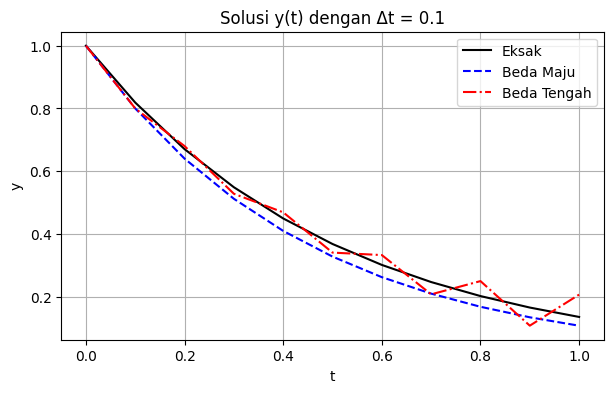

Δt = 0.010, Galat beda tengah di t=1: 0.005491
Δt = 0.010, Galat beda maju di t=1: 0.020067



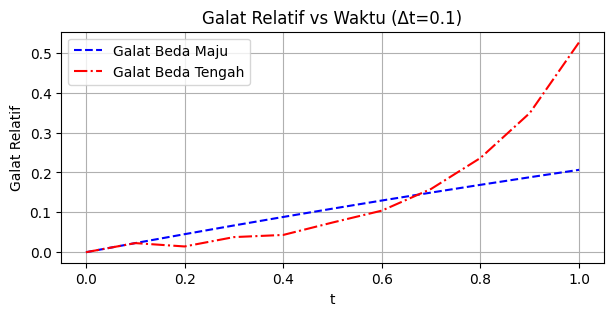

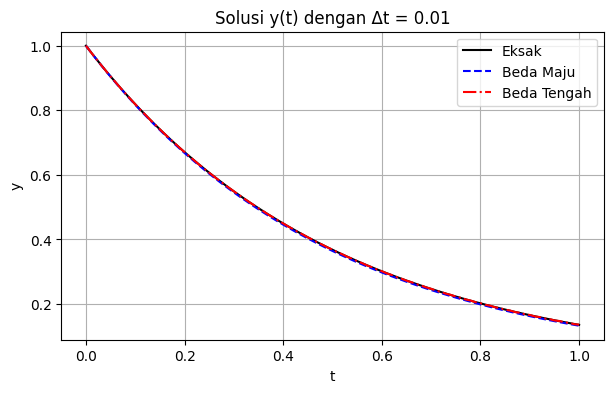

Δt = 0.001, Galat beda tengah di t=1: 0.000055
Δt = 0.001, Galat beda maju di t=1: 0.002001



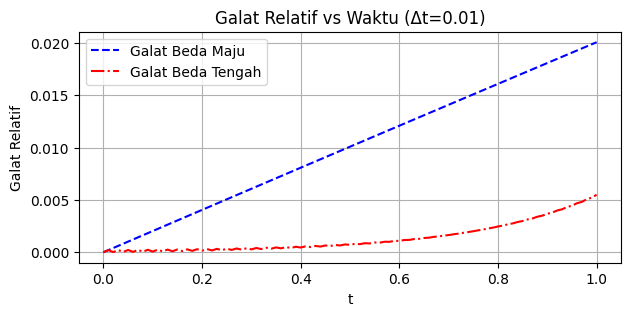

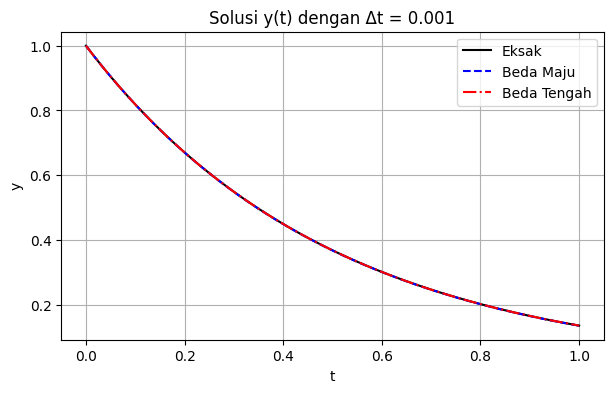

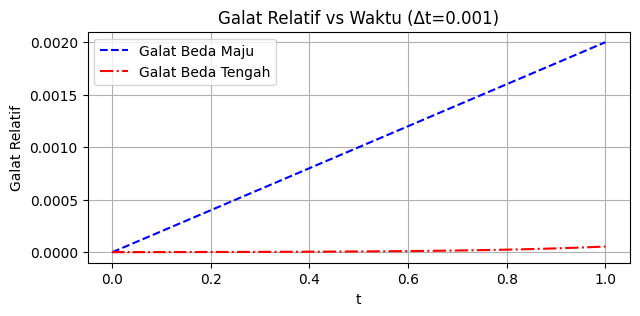

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def beda_maju(dt):
    tp = np.arange(0, 1 + dt, dt)
    y = np.zeros_like(t)
    y[0] = 1
    for i in range(1, len(t)):
        y[i] = y[i - 1] + dt * (-2 * y[i - 1])
    y_exact = np.exp(-2 * t)
    error = np.abs((y - y_exact) / y_exact)
    return t, y_exact, y, error

def beda_tengah(dt):
    t = np.arange(0, 1 + dt, dt)
    y = np.zeros_like(t)
    y[0] =1
# Nilai awal kedua dari beda maju
    y[1] = y[0] + dt * (-2 * y[0])
    for i in range(1 , len(t) - 1):
        y[i + 1] = y[i - 1] - 4 * dt * y[i]
    y_exact = np.exp(-2 * t)
    error = np.abs((y - y_exact) / y_exact)
    return t, y_exact, y, error

# Nilai Delta t
dts = [0.1, 0.01, 0.001]

for dt in dts:
    t, y_exact, y_central, err_central = beda_tengah(dt)
    _, _, y_forward, err_forward = beda_maju(dt)
    print(f"Δt = {dt:.3f}, Galat beda tengah di t=1: {err_central[-1]:.6f}")
    print(f"Δt = {dt:.3f}, Galat beda maju di t=1: {err_forward[-1]:.6f}\n")
    plt.figure(figsize=(7,4))
    plt.plot(t, y_exact, 'k-', label='Eksak')
    plt.plot(t, y_forward, 'b--', label='Beda Maju')
    plt.plot(t, y_central, 'r-.', label='Beda Tengah')
    plt.title(f'Solusi y(t) dengan Δt = {dt}')
    plt.xlabel('t'); plt.ylabel('y')
    plt.legend(); plt.grid(True)
    plt.show()
        
    plt.figure(figsize=(7,3))
    plt.plot(t, err_forward, 'b--', label='Galat Beda Maju')
    plt.plot(t, err_central, 'r-.', label='Galat Beda Tengah')
    plt.title(f'Galat Relatif vs Waktu (Δt={dt})')
    plt.xlabel('t'); plt.ylabel('Galat Relatif')
    plt.legend(); plt.grid(True)

---

## Tugas 2

Buat grafik simulasi gerak ayunan sederhana tanpa redaman menggunakan metode eksplisit dan implisit dengan panjang tali $l = 1.0 m$, sudut awal $\theta = 0.1$, kecepatan sudut awal $\omega = 0$ (dalam radian) dengan persamaan gerak:

$$\frac{d^2 \theta}{dt^2} = - \frac{g}{l} sin (\theta)$$

Untuk sudut kecil maka $sin (\theta) \approx \theta$ dan $g = 9,8m/s^2$. Waktu simulasi $t=10s$ dengan $\Delta t = 0,1$ dan $1,0s$. Ta,pilkan hasil analitis, eksplisit, dan implisit dalam satu grafik dan galatnya di grafik lain dalam satu figure seperti di samping. Berikan penurunan FDE dan kesimpulan apa yang ada peroleh dari simulasi ini? Untuk metode eksplisit carilah nilai $\Delta t$ yang menerusi syarat CFL

## Jawab:
Persamaan gerak (tanpa redaman):

$$\ddot{\theta} = -\frac{g}{l}\sin\theta \quad \Rightarrow \quad \ddot{\theta} + \omega^2 \theta = 0$$

dengan $\omega = \sqrt{\frac{g}{l}}$

Persamaan di atas dapat dituliskan sebagai sistem orde-1:

$$\begin{cases}
    \dot{\theta} = \omega_a \\
    \dot{\omega}_a = -\omega^2 \theta
\end{cases}$$

Euler eksplisit (beda maju)

$$
\begin{aligned}
\theta_{n+1} &= \theta_n + \Delta t\,\omega_{a,n} \\
\omega_{a,n+1} &= \omega_{a,n} - \Delta t\,\omega^2 \theta_n
\end{aligned}
$$

Euler implisit (beda mundur)

$$
\begin{aligned}
\theta_{n+1} &= \theta_n + \Delta t\,\omega_{a,n+1} \\
\omega_{a,n+1} &= \omega_{a,n} - \Delta t\,\omega^2 \theta_{n+1}
\end{aligned}
$$

Dengan menyelesaikan sistem linear untuk $(\theta_{n+1}, \omega_{a,n+1})$:

$$
\theta_{n+1} = 
\frac{\omega_{a,n} + \dfrac{\theta_n}{\Delta t}}
{\dfrac{1}{\Delta t} + \Delta t\,\omega^2}
$$

dan

$$
\omega_{a,n+1} = 
\frac{\theta_{n+1} - \theta_n}{\Delta t}
$$

Solusi analitis \textit{(small angel)} dengan $\theta(0) = \theta_0$, $\dot{\theta}(0) = \omega_0 = 0$:

$$\theta_{\text{exact}}(t) = \theta_0 \cos(\omega t)$$

Δt =  0.1: error eksplisit @t=10.0 s = 4.977054e+00, error implisit @t=10.0 s = 9.894296e-02


/tmp/ipykernel_14720/3355546521.py:69: UserWarning: Glyph 65535 (\uffff) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/nilam/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65535 (\uffff) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


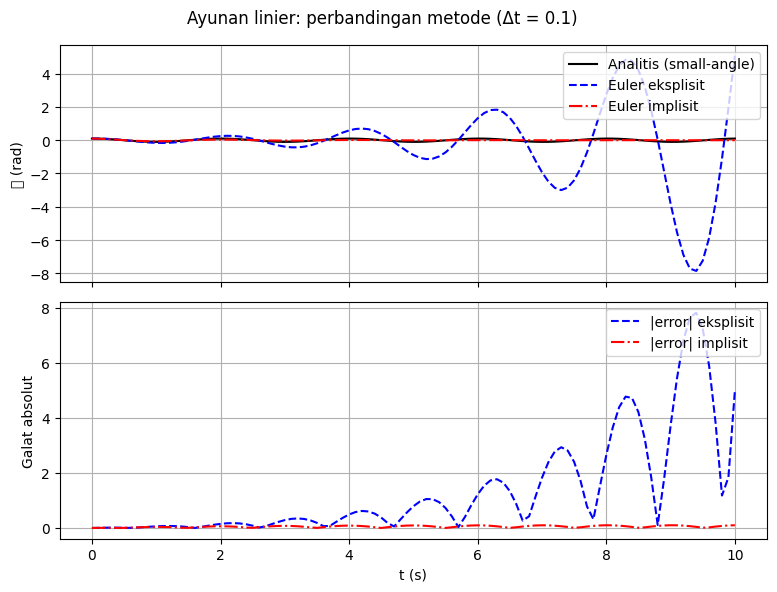

Δt =  1.0: error eksplisit @t=10.0 s = 1.467507e+04, error implisit @t=10.0 s = 9.938418e-02


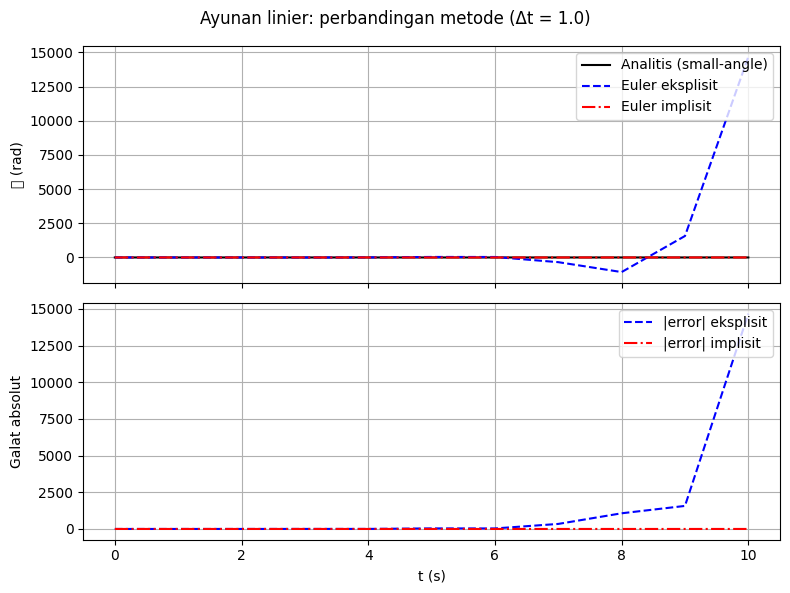

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Parameter
g = 9.8
l = 1.0
omega = np.sqrt(g / l)

# IC
theta_0 = 0.1
omega_0 = 0.0 #dtheta/dt at t = 0

def exact_solution(t):
    return theta_0 * np.cos(omega * t)

def euler_explicit(dt, tmax):
    t = np.arange(0, tmax + 1e-12, dt)
    th = np.zeros_like(t)
    om = np.zeros_like(t)
    th[0] = theta_0
    om[0] = omega_0
    for n in range(len(t) - 1):
        th[n + 1] = th[n] + dt * om[n]
        om[n + 1] = om[n] - dt * (omega**2) * th[n]
    return t, th, om

def euler_implicit(dt, tmax):
    t = np.arange(0, tmax + 1e-12, dt)
    th = np.zeros_like(t)
    om = np.zeros_like(t)
    th[0] = theta_0
    om[0] = omega_0
    for n in range(len(t) - 1):
        denom = (1.0 / dt) + dt * (omega**2)
        th_next = (om[n] + th[n] / dt) / denom
        om_next = (th_next - th[n]) / dt
        th[n + 1] = th_next
        om[n + 1] = om_next
    return t, th, om

def run_and_plot(dt, tmax=10.0):
    t = np.arange(0, tmax + 1e-12, dt)
    th_exact = exact_solution(t)
    t_exp, th_exp, _ = euler_explicit(dt, tmax)
    t_imp, th_imp, _ = euler_implicit(dt, tmax)
    
    err_exp = np.abs(th_exp - th_exact)
    err_imp = np.abs(th_imp - th_exact)
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8,6), sharex=True)
    fig.suptitle(f'Ayunan linier: perbandingan metode (Δt = {dt})')
    
    ax1.plot(t, th_exact, 'k-', label='Analitis (small-angle)')
    ax1.plot(t_exp, th_exp, 'b--', label='Euler eksplisit')
    ax1.plot(t_imp, th_imp, 'r-.', label='Euler implisit')
    ax1.set_ylabel('￿ (rad)')
    ax1.grid(True); ax1.legend(loc='upper right')
    
    ax2.plot(t_exp, err_exp, 'b--', label='|error| eksplisit')
    ax2.plot(t_imp, err_imp, 'r-.', label='|error| implisit')
    ax2.set_xlabel('t (s)')
    ax2.set_ylabel('Galat absolut')
    ax2.grid(True); ax2.legend(loc='upper right')
    
# Cetak galat di t=10 s (atau titik terakhir)
    print(f"Δt = {dt:>4}: error eksplisit @t={t[-1]:.1f} s = {err_exp[-1]:.6e}, "
    f"error implisit @t={t[-1]:.1f} s = {err_imp[-1]:.6e}")
    
    plt.tight_layout()
    plt.show()

# Jalankan untuk dua Δt
for dt in [0.1, 1.0]:
    run_and_plot(dt)